Connected to .venv (Python 3.14.5)

 # Third-party API Comparison

 Compare `aidweather` / NASA POWER with independent station observations,
 reanalysis, and satellite-derived precipitation. Sources that require local
 credentials or an official downloadable file are enabled conditionally.

In [ ]:
import pathlib
from datetime import datetime

import matplotlib.pyplot as plt
import meteostat as ms
import numpy as np
import openmeteo_requests
import pandas as pd
import requests
import requests_cache
import seaborn as sns
from retry_requests import retry

import sys

# ---------------------------------------------------------------------------
# Execution-context detection
# ---------------------------------------------------------------------------
try:
    _ipy = get_ipython()  # type: ignore[name-defined]
    IS_NOTEBOOK = _ipy is not None
except NameError:
    IS_NOTEBOOK = False

_SCRIPT_DIR = pathlib.Path(__file__).resolve().parent if not IS_NOTEBOOK else pathlib.Path(".").resolve()
if _SCRIPT_DIR.name in ("scripts", "notebooks"):
    _VALIDATION_DIR = _SCRIPT_DIR.parent
else:
    _VALIDATION_DIR = _SCRIPT_DIR

_WORKSPACE_DIR = _VALIDATION_DIR.parent.parent
sys.path.insert(0, str(_WORKSPACE_DIR / "src"))

try:
    from aidweather import PowerClient
except ImportError:
    from src.aidweather import PowerClient  # type: ignore[no-redef]

PLOT_DIR = _VALIDATION_DIR / "plots"
if not IS_NOTEBOOK:
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Plots will be saved to: {PLOT_DIR.resolve()}")


def save_or_show(filename: str) -> None:
    """Save figure to PLOT_DIR when running as a script, show inline otherwise."""
    if IS_NOTEBOOK:
        plt.show()
    else:
        out_path = PLOT_DIR / filename
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()
        print(f"Saved: {out_path}")


def add_series(
    registry: dict[str, pd.Series],
    name: str,
    series: pd.Series,
) -> None:
    """Normalize date index, drop duplicate dates, and add a named daily series."""
    clean = series.copy()
    clean.index = pd.to_datetime(clean.index).normalize()
    clean = clean[~clean.index.duplicated(keep="last")].sort_index()
    registry[name] = clean.rename(name)

 ## 1. Source scope

 Existing sources:
 - AidWeather: AidBio's NASA POWER client.
 - NASA POWER direct: transport/parity test for AidWeather, not an independent dataset.
 - Meteostat: station-derived/interpolated observations.
 - Open-Meteo: explicit ERA5-Land historical reanalysis.

 Added sources:
 - INMET BDMEP: local official INMET export, auto-selected from data folder.

 ## 2. Location & configuration

In [ ]:
lat, lon = -15.7975, -47.8919  # Brasília coordinates
start, end = datetime(2025, 1, 1), datetime(2025, 12, 31)
date_index = pd.date_range(start=start, end=end, freq="D")

# Path to local INMET BDMEP CSV files folder
INMET_DATA_DIR = _VALIDATION_DIR / "data" / str(start.year)

print(f"Latitude: {lat} | Longitude: {lon}")
print(f"Date start: {start.date()} | Date end: {end.date()}")

temperature_series: dict[str, pd.Series] = {}
precipitation_series: dict[str, pd.Series] = {}

Latitude: -15.7975 | Longitude: -47.8919
Date start: 2025-01-01 | Date end: 2025-12-31


 ## 3. Source helpers

In [ ]:
def haversine_km(
    lat1: float,
    lon1: float,
    lat2: pd.Series,
    lon2: pd.Series,
) -> pd.Series:
    """Distance from one coordinate to a vector of station coordinates."""
    r = 6371.0088
    p1 = np.radians(lat1)
    p2 = np.radians(lat2.astype(float))
    dp = np.radians(lat2.astype(float) - lat1)
    dl = np.radians(lon2.astype(float) - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


def find_closest_inmet_csv(
    data_dir: pathlib.Path,
    target_lat: float,
    target_lon: float,
) -> pathlib.Path | None:
    """Find the closest INMET station CSV in the directory to target coordinates.

    Reads the first 8 lines of each CSV file to extract LATITUDE and LONGITUDE.
    """
    if not data_dir.is_dir():
        return None

    best_path = None
    min_dist = float("inf")

    # Support uppercase and lowercase file extensions
    csv_files = list(data_dir.glob("*.CSV")) + list(data_dir.glob("*.csv"))
    for path in csv_files:
        try:
            lat_val = None
            lon_val = None
            with open(path, encoding="latin1") as f:
                for _ in range(8):
                    line = f.readline()
                    if not line:
                        break
                    parts = line.strip().split(";")
                    if len(parts) >= 2:
                        key = parts[0].upper().strip()
                        val = parts[1].replace(",", ".").strip()
                        if "LATITUDE" in key:
                            lat_val = float(val)
                        elif "LONGITUDE" in key:
                            lon_val = float(val)

            if lat_val is not None and lon_val is not None:
                dist = (lat_val - target_lat) ** 2 + (lon_val - target_lon) ** 2
                if dist < min_dist:
                    min_dist = dist
                    best_path = path
        except Exception:
            continue

    return best_path


def robust_parse_dates(series: pd.Series) -> pd.Series:
    """Robustly parse date series containing YYYY/MM/DD or DD/MM/YYYY."""
    sample_series = series.dropna()
    if sample_series.empty:
        return pd.to_datetime(series, errors="coerce")
    sample = str(sample_series.iloc[0]).strip()
    if len(sample) >= 4 and sample[:4].isdigit():
        return pd.to_datetime(series, dayfirst=False, errors="coerce")
    return pd.to_datetime(series, dayfirst=True, errors="coerce")


def load_inmet_bdmeP_temperature(
    csv_path: str,
    start_date: datetime,
    end_date: datetime,
) -> pd.Series:
    """Load a locally downloaded INMET BDMEP CSV export.

    BDMEP formats vary by export and station era. This reader detects common
    Portuguese date and air-temperature headers, then parses decimal commas.
    """
    raw = pd.read_csv(
        csv_path,
        sep=";",
        encoding="latin1",
        skiprows=8,
        dtype=str,
        engine="python",
    )
    raw.columns = [str(c).strip() for c in raw.columns]
    normalized = {c: c.upper().replace(" ", "_") for c in raw.columns}

    date_col = next(
        (c for c, n in normalized.items() if "DATA" in n or n in {"DATE", "YYYYMMDD"}),
        None,
    )
    temp_candidates = [
        c
        for c, n in normalized.items()
        if "TEMP" in n and ("MEDIA" in n or "COMPENSADA" in n or "BULBO_SECO" in n)
    ]
    if date_col is None or not temp_candidates:
        raise ValueError(
            "Could not identify INMET date and mean-temperature columns. "
            "Inspect the export header and adapt the column-selection rules."
        )

    data = raw[[date_col, temp_candidates[0]]].copy()
    data.columns = ["date", "temperature"]
    data["date"] = robust_parse_dates(data["date"])
    data["temperature"] = pd.to_numeric(
        data["temperature"].str.replace(",", ".", regex=False),
        errors="coerce",
    )
    data = data.dropna(subset=["date"]).set_index("date").sort_index()
    return data.loc[pd.Timestamp(start_date) : pd.Timestamp(end_date), "temperature"]

 ## 4. Data acquisition

 ### A. AidWeather

In [ ]:
try:
    client = PowerClient(temporal_api="daily")
    df_aidweather = client.get_point_data(
        lat=lat,
        lon=lon,
        start=start,
        end=end,
        params=["T2M", "PRECTOTCORR"],
    )
    add_series(temperature_series, "T2M_AIDWEATHER", df_aidweather["T2M"])
    add_series(precipitation_series, "PRECTOT_AIDWEATHER", df_aidweather["PRECTOTCORR"])
    print("AidWeather fetched successfully.")
except Exception as e:
    print(f"AidWeather failed: {e}")

AidWeather fetched successfully.


 ### B. Meteostat

In [ ]:
try:
    point = ms.Point(lat, lon)
    stations = ms.stations.nearby(point, limit=4)
    ts = ms.daily(stations, start, end)
    df_meteostat = ms.interpolate(ts, point).fetch()

    add_series(temperature_series, "T2M_METEOSTAT", df_meteostat["temp"])
    if "prcp" in df_meteostat:
        add_series(precipitation_series, "PRECTOT_METEOSTAT", df_meteostat["prcp"])
    print("Meteostat fetched successfully.")
except Exception as e:
    print(f"Meteostat failed: {e}")

Meteostat fetched successfully.


 ### C. NASA POWER direct API — parity check, not independent validation

In [ ]:
try:
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "T2M,PRECTOTCORR",
        "community": "ag",
        "latitude": lat,
        "longitude": lon,
        "start": start.strftime("%Y%m%d"),
        "end": end.strftime("%Y%m%d"),
        "format": "JSON",
    }
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    nasa_parameters = response.json()["properties"]["parameter"]

    df_nasa = pd.DataFrame(
        {
            "T2M_NASA_DIRECT": pd.Series(nasa_parameters["T2M"]),
            "PRECTOT_NASA_DIRECT": pd.Series(nasa_parameters["PRECTOTCORR"]),
        }
    )
    df_nasa.index = pd.to_datetime(df_nasa.index, format="%Y%m%d")
    add_series(temperature_series, "T2M_NASA_DIRECT", df_nasa["T2M_NASA_DIRECT"])
    add_series(
        precipitation_series, "PRECTOT_NASA_DIRECT", df_nasa["PRECTOT_NASA_DIRECT"]
    )
    print("NASA POWER direct API fetched successfully.")
except Exception as e:
    print(f"NASA POWER direct API failed: {e}")

NASA POWER direct API fetched successfully.


 ### D. Open-Meteo Archive API — explicitly request ERA5-Land

In [ ]:
try:
    cache_session = requests_cache.CachedSession(".cache", expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start.strftime("%Y-%m-%d"),
        "end_date": end.strftime("%Y-%m-%d"),
        "daily": ["temperature_2m_mean", "precipitation_sum"],
        "timezone": "America/Sao_Paulo",
        "models": "era5_land",
    }
    responses = openmeteo.weather_api(url, params=params)
    daily = responses[0].Daily()
    variable_names = [
        daily.Variables(i).Variable() for i in range(daily.VariablesLength())
    ]
    values = {
        variable_names[i]: daily.Variables(i).ValuesAsNumpy()
        for i in range(daily.VariablesLength())
    }

    # The order follows the requested daily variables.
    df_openmeteo = pd.DataFrame(
        {
            "T2M_OPENMETEO_ERA5LAND": values[variable_names[0]],
            "PRECTOT_OPENMETEO_ERA5LAND": values[variable_names[1]],
        },
        index=date_index,
    )
    add_series(
        temperature_series,
        "T2M_OPENMETEO_ERA5LAND",
        df_openmeteo["T2M_OPENMETEO_ERA5LAND"],
    )
    add_series(
        precipitation_series,
        "PRECTOT_OPENMETEO_ERA5LAND",
        df_openmeteo["PRECTOT_OPENMETEO_ERA5LAND"],
    )
    print("Open-Meteo ERA5-Land fetched successfully.")
except Exception as e:
    print(f"Open-Meteo ERA5-Land failed: {e}")

Open-Meteo ERA5-Land fetched successfully.


 ### E. INMET BDMEP — local official Brazilian station export

 Automatically detects the closest CSV file in the local data directory matching the requested coordinates.

In [ ]:
inmet_target_path = find_closest_inmet_csv(INMET_DATA_DIR, lat, lon)

if inmet_target_path:
    try:
        print(f"Loading closest INMET BDMEP station from: {inmet_target_path.name}")
        inmet_temperature = load_inmet_bdmeP_temperature(
            str(inmet_target_path), start, end
        )
        add_series(temperature_series, "T2M_INMET_BDMEP", inmet_temperature)
        print("INMET BDMEP local export loaded successfully.")
    except Exception as e:
        print(f"INMET BDMEP failed to load: {e}")
else:
    print(f"INMET BDMEP skipped: no valid CSV found in {INMET_DATA_DIR}")

Loading closest INMET BDMEP station from: INMET_CO_DF_A001_BRASILIA_01-01-2025_A_31-12-2025.CSV
INMET BDMEP local export loaded successfully.


 ## 5. Comparison and metrics

 Outer joins retain every source. Pairwise metrics only use dates where both
 AidWeather and the comparator are present.

In [ ]:
temperature_comparison = pd.concat(temperature_series.values(), axis=1).sort_index()
precipitation_comparison = pd.concat(precipitation_series.values(), axis=1).sort_index()


def metrics_against_aidweather(
    frame: pd.DataFrame,
    baseline: str,
) -> pd.DataFrame:
    rows = []
    if baseline not in frame:
        return pd.DataFrame()

    for source in frame.columns:
        if source == baseline:
            continue
        pair = frame[[baseline, source]].dropna()
        if pair.empty:
            continue
        diff = pair[source] - pair[baseline]
        rows.append(
            {
                "source": source,
                "n_overlap_days": len(pair),
                "coverage_of_baseline_pct": 100
                * len(pair)
                / frame[baseline].notna().sum(),
                "mean_bias": diff.mean(),
                "mae": diff.abs().mean(),
                "rmse": np.sqrt(np.mean(np.square(diff))),
                "pearson_r": pair[baseline].corr(pair[source], method="pearson"),
                "spearman_rho": pair[baseline].corr(pair[source], method="spearman"),
            }
        )
    return pd.DataFrame(rows).set_index("source").sort_values("rmse")


print("=== Temperature comparison metrics against AidWeather ===")
print(metrics_against_aidweather(temperature_comparison, "T2M_AIDWEATHER").round(3))

print("\n=== Precipitation comparison metrics against AidWeather ===")
print(
    metrics_against_aidweather(precipitation_comparison, "PRECTOT_AIDWEATHER").round(3)
)

=== Temperature comparison metrics against AidWeather ===
                        n_overlap_days  coverage_of_baseline_pct  mean_bias  \
source                                                                        
T2M_NASA_DIRECT                    365                     100.0      0.000   
T2M_OPENMETEO_ERA5LAND             365                     100.0     -1.928   
T2M_METEOSTAT                      365                     100.0     -1.963   
T2M_INMET_BDMEP                    365                     100.0     -2.001   

                          mae   rmse  pearson_r  spearman_rho  
source                                                         
T2M_NASA_DIRECT         0.000  0.000      1.000         1.000  
T2M_OPENMETEO_ERA5LAND  1.930  2.109      0.922         0.916  
T2M_METEOSTAT           1.971  2.243      0.874         0.871  
T2M_INMET_BDMEP         2.115  2.647      0.707         0.709  

=== Precipitation comparison metrics against AidWeather ===
                     n

 ## 6. Visualizations

 ### A. Daily 2-m temperature time series

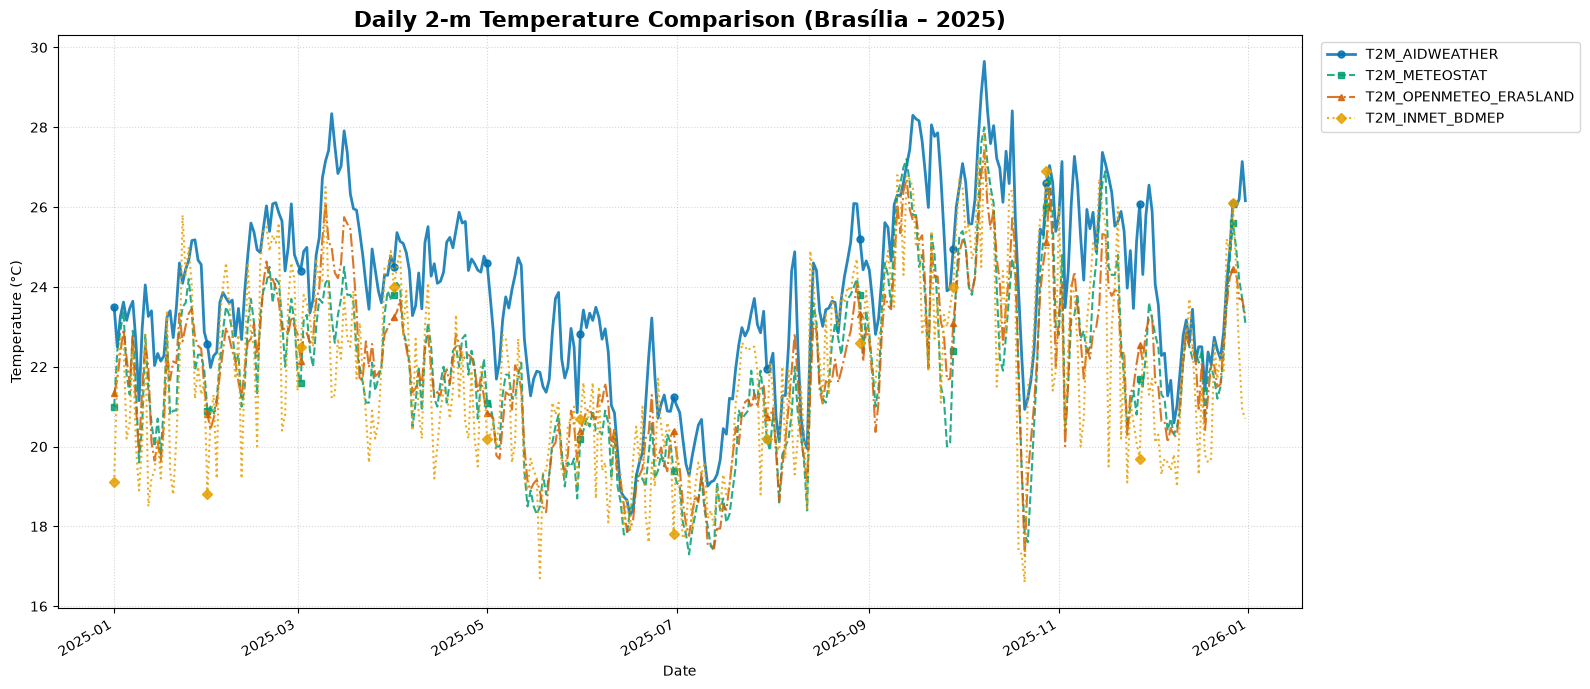

In [ ]:
_SOURCE_STYLES: list[dict] = [
    {"color": "#0072B2", "linestyle": "-", "marker": "o", "linewidth": 2.0},
    {"color": "#009E73", "linestyle": "--", "marker": "s", "linewidth": 1.5},
    {"color": "#D55E00", "linestyle": "-.", "marker": "^", "linewidth": 1.5},
    {"color": "#E69F00", "linestyle": ":", "marker": "D", "linewidth": 1.5},
    {"color": "#CC79A7", "linestyle": "--", "marker": "v", "linewidth": 1.5},
    {"color": "#56B4E9", "linestyle": "-", "marker": "P", "linewidth": 1.5},
]
marker_every = max(1, len(temperature_comparison) // 12)

fig, ax = plt.subplots(figsize=(16, 7))
plot_idx = 0
for column in temperature_comparison.columns:
    if column == "T2M_NASA_DIRECT":
        continue
    style = _SOURCE_STYLES[plot_idx % len(_SOURCE_STYLES)]
    plot_idx += 1
    ax.plot(
        temperature_comparison.index,
        temperature_comparison[column],
        label=column,
        color=style["color"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        markevery=marker_every,
        markersize=5,
        linewidth=style["linewidth"],
        alpha=0.85,
    )
ax.set_title(
    "Daily 2-m Temperature Comparison (Brasília – 2025)", fontsize=16, fontweight="bold"
)
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
ax.grid(True, linestyle=":", alpha=0.5)
fig.autofmt_xdate()
plt.tight_layout()
save_or_show("temperature_timeseries_comparison.png")

 ### B. Clear-cut diagnostic: Bland–Altman bias plot

 This is the added visualization. It makes systematic disagreement obvious:
 the y-axis is source minus AidWeather, while the x-axis is their mean value.
 A flat cloud centered near zero means close agreement; slope or spread
 changing across the range indicates conditional bias or heteroscedasticity.

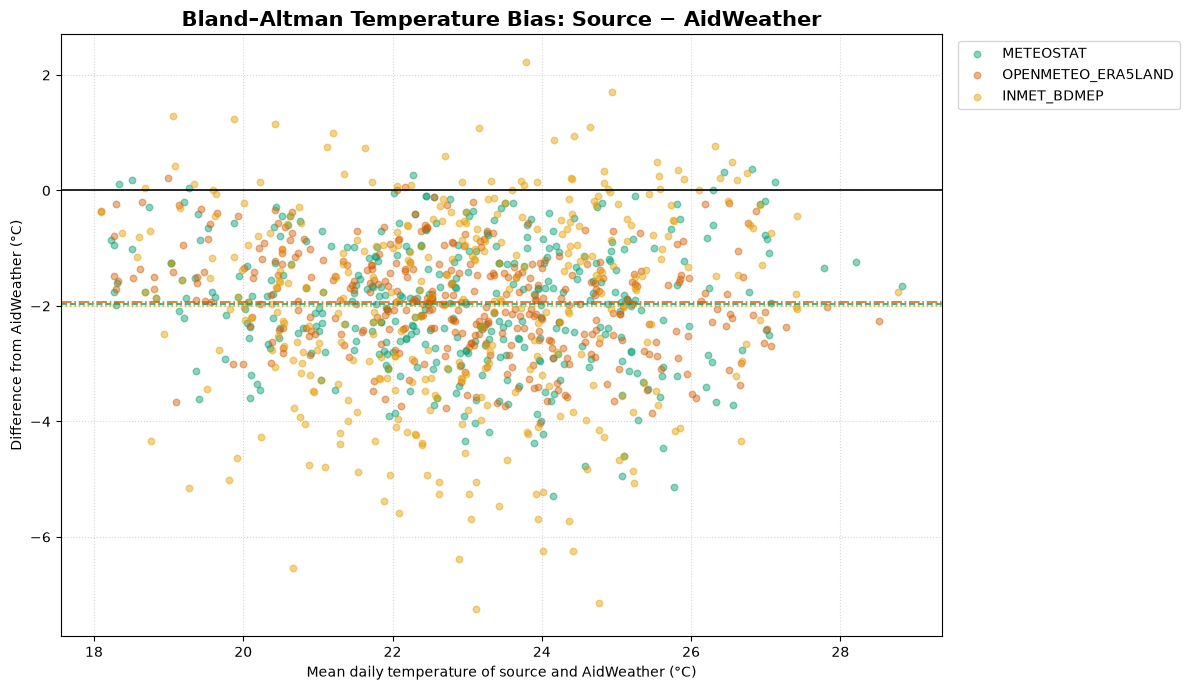

In [ ]:
baseline = "T2M_AIDWEATHER"
comparators = [
    c
    for c in temperature_comparison.columns
    if c != baseline and c != "T2M_NASA_DIRECT"
]
if baseline in temperature_comparison and comparators:
    fig, ax = plt.subplots(figsize=(12, 7))
    for i, source in enumerate(comparators):
        pair = temperature_comparison[[baseline, source]].dropna()
        if pair.empty:
            continue
        mean_temperature = pair[[baseline, source]].mean(axis=1)
        difference = pair[source] - pair[baseline]
        style = _SOURCE_STYLES[(i + 1) % len(_SOURCE_STYLES)]

        ax.scatter(
            mean_temperature,
            difference,
            label=source.replace("T2M_", ""),
            color=style["color"],
            alpha=0.45,
            s=22,
        )
        ax.axhline(
            difference.mean(),
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=1.2,
            alpha=0.9,
        )

    ax.axhline(0, color="black", linewidth=1.2)
    ax.set_title(
        "Bland–Altman Temperature Bias: Source − AidWeather",
        fontsize=15,
        fontweight="bold",
    )
    ax.set_xlabel("Mean daily temperature of source and AidWeather (°C)")
    ax.set_ylabel("Difference from AidWeather (°C)")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    save_or_show("temperature_bland_altman_bias.png")

 ### C. Daily precipitation comparison

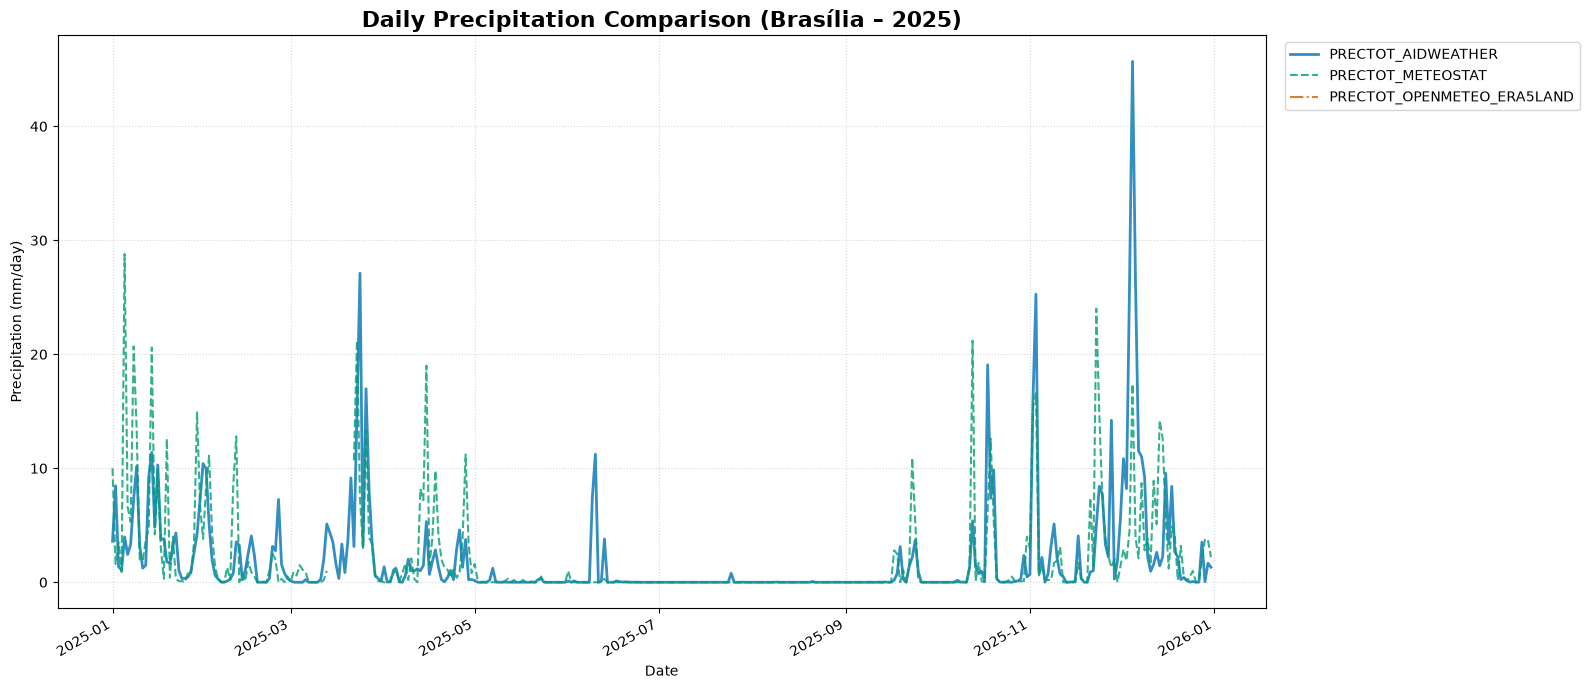

In [ ]:
if not precipitation_comparison.empty:
    fig, ax = plt.subplots(figsize=(16, 7))
    plot_idx = 0
    for column in precipitation_comparison.columns:
        if column == "PRECTOT_NASA_DIRECT":
            continue
        style = _SOURCE_STYLES[plot_idx % len(_SOURCE_STYLES)]
        plot_idx += 1
        ax.plot(
            precipitation_comparison.index,
            precipitation_comparison[column],
            label=column,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            alpha=0.8,
        )
    ax.set_title(
        "Daily Precipitation Comparison (Brasília – 2025)",
        fontsize=16,
        fontweight="bold",
    )
    ax.set_ylabel("Precipitation (mm/day)")
    ax.set_xlabel("Date")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    ax.grid(True, linestyle=":", alpha=0.5)
    fig.autofmt_xdate()
    plt.tight_layout()
    save_or_show("precipitation_timeseries_comparison.png")

 ### D. Correlation heatmap for temperature sources

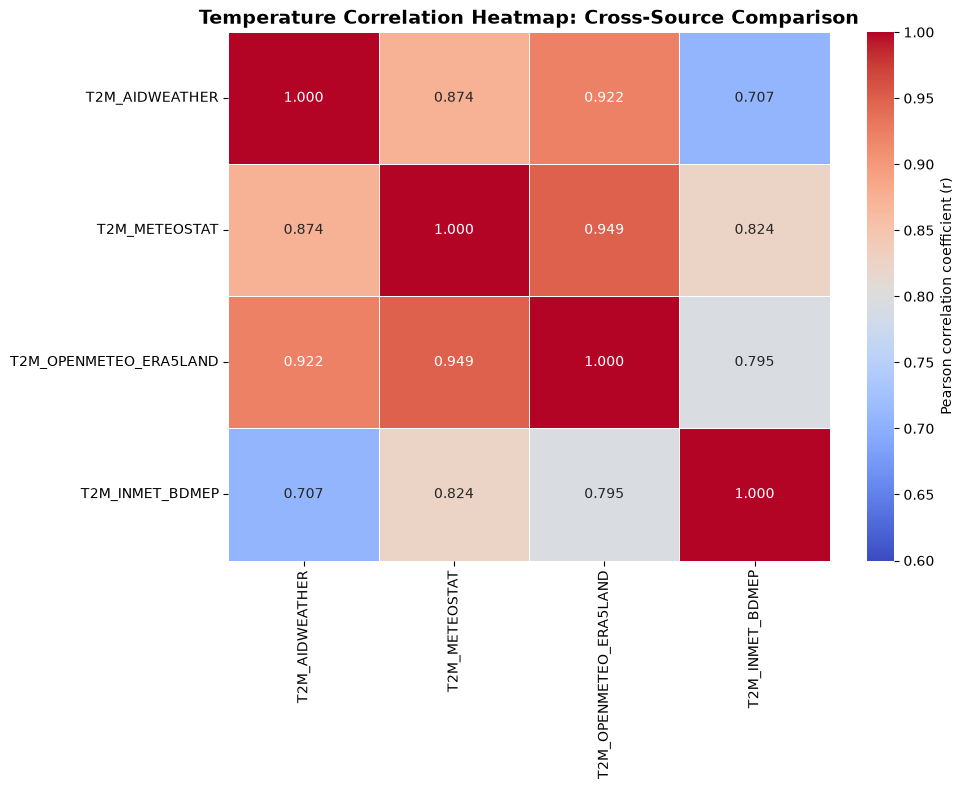

In [ ]:
if temperature_comparison.shape[1] >= 2:
    # Drop NASA direct to keep the correlation heatmap readable and clean
    heatmap_df = temperature_comparison.drop(
        columns=["T2M_NASA_DIRECT"], errors="ignore"
    )
    corr_matrix = heatmap_df.corr(method="pearson")
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".3f",
        vmin=0.6,
        vmax=1.0,
        linewidths=0.5,
        cbar_kws={"label": "Pearson correlation coefficient (r)"},
    )
    plt.title(
        "Temperature Correlation Heatmap: Cross-Source Comparison",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    save_or_show("temperature_correlation_heatmap.png")